In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import yfinance as yf
from community import best_partition

In [5]:
sp500_tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B",
    "JPM", "JNJ", "V", "UNH", "XOM", "PG", "MA", "HD", "CVX", "MRK",
    "ABBV", "PEP", "KO", "AVGO", "COST", "MCD", "WMT", "BAC", "CRM",
    "ACN", "LLY", "TMO", "CSCO", "ABT", "NKE", "NEE", "DHR", "TXN",
    "ORCL", "PM", "MS", "RTX", "AMGN", "HON", "UPS", "QCOM", "IBM",
    "GS", "CAT", "SBUX", "BA", "GE"
]
crypto_tickers = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]
all_tickers = sp500_tickers + crypto_tickers

raw = yf.download(all_tickers, start="2019-01-01", end="2024-12-31", auto_adjust=True)
prices = raw.xs("Close", axis=1, level="Price")
prices = prices.dropna(how="all")
prices = prices.dropna(axis=1, thresh=int(0.5 * len(prices)))
returns = np.log(prices / prices.shift(1)).dropna(how="all")
corr_matrix = returns.corr()

threshold = 0.5
G = nx.Graph()
G.add_nodes_from(corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        asset_i = corr_matrix.columns[i]
        asset_j = corr_matrix.columns[j]
        correlation = corr_matrix.loc[asset_i, asset_j]
        if correlation > threshold:
            G.add_edge(asset_i, asset_j, weight=correlation)

print(f"Network ready — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

[*********************100%***********************]  55 of 55 completed


Network ready — 55 nodes, 242 edges


In [8]:
partition = best_partition(G, weight="weight", random_state=42)

#Count how many communities were found
n_communities = len(set(partition.values()))
print(f"Number of communities detected: {n_communities}")

#Show which community each asset belongs to
partition_df = pd.DataFrame.from_dict(partition, orient="index", columns=["community"])
partition_df = partition_df.sort_values("community")

for community_id in range(n_communities):
    members = partition_df[partition_df["community"] == community_id]
    print(f"\nCommunity {community_id};: {members}")


Number of communities detected: 11

Community 0;:        community
AAPL           0
ACN            0
AVGO           0
AMZN           0
CSCO           0
COST           0
CRM            0
GOOGL          0
META           0
ORCL           0
TXN            0
WMT            0
QCOM           0
MSFT           0
NVDA           0

Community 1;:       community
ABBV          1

Community 2;:      community
UPS          2

Community 3;:        community
HON            3
IBM            3
GE             3
CVX            3
GS             3
MS             3
XOM            3
RTX            3
JPM            3
BRK-B          3
CAT            3
BA             3
BAC            3

Community 4;:          community
ETH-USD          4
BTC-USD          4
SOL-USD          4
BNB-USD          4
XRP-USD          4

Community 5;:       community
PM            5
JNJ           5
KO            5
DHR           5
ABT           5
AMGN          5
TMO           5
NEE           5
PEP           5
PG            5

Community 6;

The algo never saw a single label, sector or name, and yet found very interesting information (that we know) :
-   Community 0 \Tech & Growth : AAPL, MSFT, GOOGL, AMZN, NVDA, META, CSCO, CRM, AVGO, etc. Those are predominantly tech and digital economy.
-   Community 3 \Industrials\Financials\Energy : GS, MS, JPM, BAC, BRK-B mixed with XOM, CVX, GE, CAT, BA, HON, RTX, IBM. 
-   Community 5 \Defensives : JNJ, PG, KO, PEP, PM, etc. Classic defensive stocks - consumer staples, healthcare, utilities. These are the stocks people hold during recessions. 
-   Community 6 \Consumer discretionary : MCD, MA, V, HD, SBUX, etc. Consumer spending plays - all sensitive to the same economic cycle of consumer confidence and spending.
-   Community 4 \Crypto : BTC, ETH, BNB, SOL, XRP. Perfectly isolated, as expected.
-   Communities 1, 2, 7, 8, 9, 10 - ABBV, UPS, LLY, MRK, TSLA, UNH, each in their own community. These are the isolated nodes we found on day (nodes with no edges above 0.5)

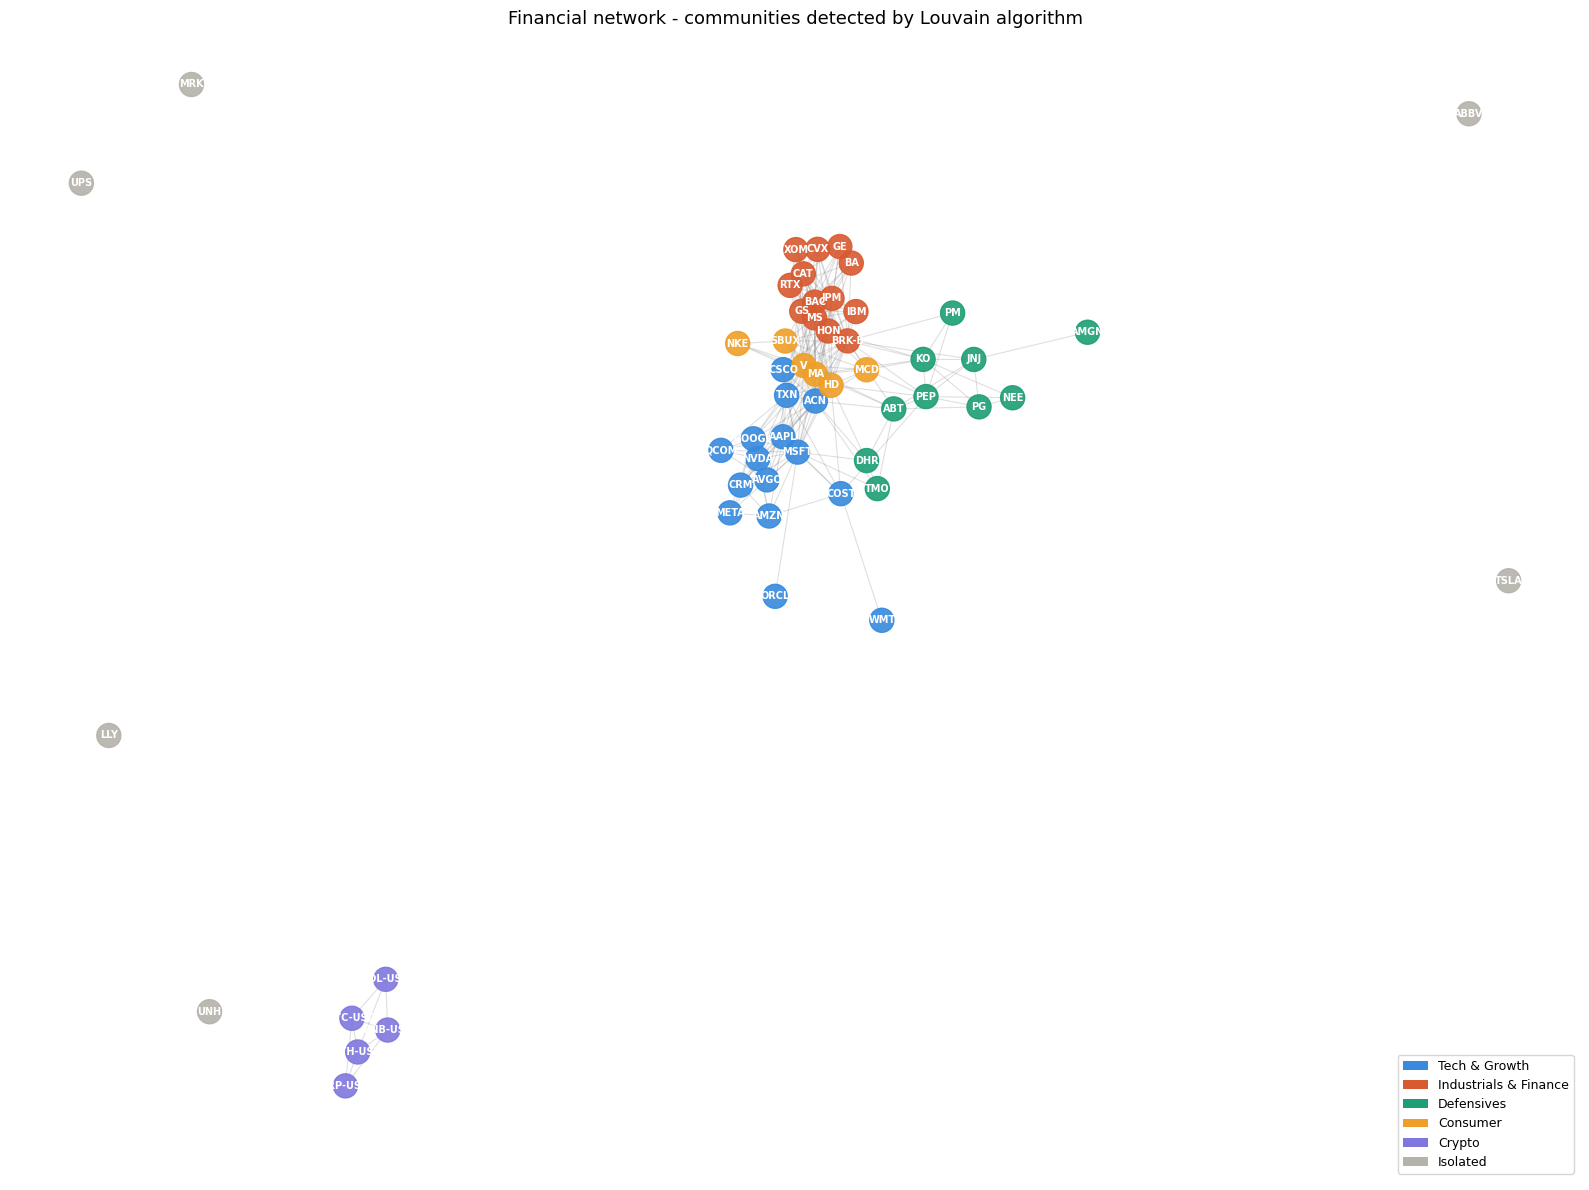

In [11]:
#Label communities with meaningful names
community_labels = {
    0: "Tech & Growth",
    3: "Industrials & Finance",
    5: "Defensives",
    6: "Consumer",
    4: "Crypto",
    1: "Isolated", 2: "Isolated", 7: "Isolated",
    8: "Isolated", 9: "Isolated", 10: "Isolated"
}

#Map labels back to nodes
node_community_label = {
    node: community_labels[community_id]
    for node, community_id in partition.items()
}

#Assign colors per community label
color_map = {
    "Tech & Growth":        "#378ADD",
    "Industrials & Finance": "#D85A30",
    "Defensives":           "#1D9E75",
    "Consumer":             "#EF9F27",
    "Crypto":               "#7F77DD",
    "Isolated":             "#B4B2A9"
}

node_colors = [color_map[node_community_label[node]] for node in G.nodes()]

#Plot
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, weight="weight", seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, width=0.8, alpha=0.25, edge_color="gray")

#Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=label) for label, color in color_map.items()]
plt.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.title("Financial network - communities detected by Louvain algorithm", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("community_network.png", dpi=150)
plt.show()


## Community detection findings

The Louvain algorithm recovered economically meanigful sectors purely from correlation structure.

Detected communities : 
-   Tech & Growth (blue): 15 stocks  - digital economy cluster
-   Industrials & Finance (orange): 13 stocks - old economy cluster
-   Defensives (green): 10 stocks - recession-resistant cluster
-   Consumer (yellow): 6 stocks - consumer spending cluster
-   Crypto (purple): 5 assets - completly isolated from equities
Key observations: community boundaries align closely with GICS sector classifications, validating that price correlation captures fundamental economic relationships.

Isolated nodes (TSLA, LLY, MRK, UNH, ABBV, UPS) have idiosyncratic risk drivers that don't aligh with any sector cluster - making them natural diversifiers in portofolio constuction.

Just a quick note on the Louvain algo, it is essentially asking this question "if edges were distributed randomly but node degrees stayed the same, how much connection would we expect between i and j by chance? You subtract this from the actual connection to measure how much better than random your community structure is.
So it is essentially measuring the part of the structure that is not due to pure randomness. It is trying to capture that information.